In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Lambda, Concatenate
from tensorflow.keras.utils import plot_model
from tensorflow.keras import Input, Model, regularizers

In [7]:
class ReconstructionAccuracy(tf.keras.metrics.Metric):

    def __init__(self, **kwargs):
        super().__init__(name='reconstruction_accuracy', **kwargs)
        self.total   = self.add_weight(name='total',   initializer='zeros')
        self.count   = self.add_weight(name='count',   initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        preds   = tf.cast(y_pred >= 0.5, tf.float32)
        correct = tf.cast(tf.equal(preds, tf.cast(y_true, tf.float32)), tf.float32)
        self.total.assign_add(tf.reduce_sum(correct))
        self.count.assign_add(tf.cast(tf.size(correct), tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.)
        self.count.assign(0.)

def split_data(X, y, rs=42, tt_split=0.6, tv_split=0.5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=tt_split, random_state=rs, stratify=y)
    X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=tv_split, random_state=rs, stratify=y_test)
    return X_train, X_test, X_val, y_train, y_test, y_val

phishing_websites = fetch_ucirepo(id=327)
X = phishing_websites.data.features
y = phishing_websites.data.targets

binary_columns = X.columns[X.nunique() == 2]
ternary_columns = X.columns.drop(binary_columns)
X_scaled = X.copy()
X_scaled[binary_columns] = (X_scaled[binary_columns] + 1) // 2
X_scaled[ternary_columns] = X_scaled[ternary_columns] + 1
oh_encode = OneHotEncoder(
    sparse_output=False
)
oh_encoded = oh_encode.fit_transform(X_scaled[ternary_columns])
oh_encoded_df = pd.DataFrame(
    oh_encoded,
    columns=oh_encode.get_feature_names_out(),
    dtype=int
)
X_one_hot = pd.concat([X_scaled[binary_columns], oh_encoded_df], axis=1) 
y_scaled = y.copy()
y_scaled.loc[y_scaled['result'] == -1, 'result'] = 0

In [10]:
exclude_from_dim_red_cols = ['having_at_symbol',
 'age_of_domain',
 'page_rank',
 'google_index',
 'statistical_report']

encode_cols = [c for c in X_one_hot.columns if c not in exclude_from_dim_red_cols]
bypass_cols = exclude_from_dim_red_cols

encode_idx = [X_one_hot.columns.get_loc(c) for c in encode_cols]
bypass_idx = [X_one_hot.columns.get_loc(c) for c in bypass_cols]

FULL_INPUT_SIZE = len(X_one_hot.columns)

## Model Input Layer
full_input = Input(shape=(FULL_INPUT_SIZE,), name="dataframe_input")

## Separate Data To Encode
encoded_part = Lambda(
    lambda x: tf.gather(x, encode_idx, axis=1),
    name="encoded_feature_slice"
)(full_input)

## Separate Data For Bypass
bypass_part = Lambda(
    lambda x: tf.gather(x, bypass_idx, axis=1),
    name="bypass_feature_slice"
)(full_input)

## Autoencoder Hyperparameters
ENCODER_INPUT_SIZE = len(encode_cols)
ENCODER_HIDDEN_DIM = ENCODER_INPUT_SIZE // 2
ENCODER_LATENT_DIM = 7

## Build Encoder
enc_input_layer = Input(shape=(ENCODER_INPUT_SIZE, ), name='encoder_input')
enc_hidden_layer = Dense(ENCODER_HIDDEN_DIM, activation='sigmoid', activity_regularizer=regularizers.l1(10e-5), name="encoder_dense")(enc_input_layer)
enc_output_layer = Dense(ENCODER_LATENT_DIM, activation='tanh', name='latent_output')(enc_hidden_layer)
enc = Model(inputs=enc_input_layer, outputs=enc_output_layer, name="Encoder")

## Build Decoder
dec_input_layer = Input(shape=(ENCODER_LATENT_DIM,), name='decoder_input')
dec_hidden_layer = Dense(ENCODER_HIDDEN_DIM, activation="tanh", name='decoder_dense')(dec_input_layer)
dec_output_layer = Dense(ENCODER_INPUT_SIZE, activation="sigmoid", name='reconstruction')(dec_hidden_layer)
dec = Model(inputs=dec_input_layer, outputs=dec_output_layer, name="Decoder")

## Set Up Encoder Structure
latent = enc(encoded_part)
reconstruction = dec(latent)

## Build Input Connection To Classifier
cls_input = Concatenate(name="classifier_concat")([latent, bypass_part])

## Classifier Hyperparameters
CLASSIFIER_INPUT_SIZE = ENCODER_LATENT_DIM + len(bypass_cols)
CLASSIFIER_HIDDEN_SIZE = CLASSIFIER_INPUT_SIZE // 2
CLASSIFIER_OUTPUT_SIZE = 1

## Building the classifier
cls_input_layer = Input(shape=(CLASSIFIER_INPUT_SIZE,), name='classifier_input')
cls_hidden_layer = Dense(CLASSIFIER_HIDDEN_SIZE, activation='relu', name='classifier_dense')(cls_input_layer)
cls_output_layer = Dense(CLASSIFIER_OUTPUT_SIZE, activation='sigmoid', name="prediction")(cls_hidden_layer)
cls_model = Model(cls_input_layer, cls_output_layer, name="Classifier")

## Make Classifier Connections
prediction = cls_model(cls_input)

## Build Complete Model
full_multi_output_model = Model(
    inputs=full_input,
    outputs=[reconstruction, prediction],
    name="autoencoder_classifier_joint_model"
)

plot_model(
    full_multi_output_model,
    to_file="./images/full_model_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=200
)

full_multi_output_model.summary()

Model: "autoencoder_classifier_joint_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dataframe_input     │ (None, 46)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoded_feature_sl… │ (None, 41)        │          0 │ dataframe_input[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder             │ (None, 7)         │        987 │ encoded_feature_… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bypass_feature_sli… │ (None, 5)         │          0 │ dataframe_input[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_concat   │ (None, 12)        │          0 │ Encoder[0][0],    │
│ (Concatenate)       │                   │            │ bypass_feature_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder             │ (None, 41)        │      1,021 │ Encoder[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Classifier          │ (None, 1)         │         85 │ classifier_conca… │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,093 (8.18 KB)

 Trainable params: 2,093 (8.18 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
X_train, X_test, X_val, y_train, y_test, y_val = split_data(X_one_hot, y_scaled)

full_multi_output_model.compile(
    optimizer="adam",
    loss={
        "Decoder": "mse",
        "Classifier": "binary_crossentropy" 
    },
    metrics={
        "Decoder": [],#ReconstructionAccuracy(),
        "Classifier": []
    },
    loss_weights={
        "Decoder": 1.0,
        "Classifier": 1.0
    }
)

multi_model_history = full_multi_output_model.fit(
    X_train,
    {
        "Decoder": X_train.iloc[:, encode_idx], 
        "Classifier": y_train
    },
    epochs=200,
    batch_size=32,
    validation_data=(
        X_test, 
        {
            "Decoder": X_test.iloc[:, encode_idx], 
            "Classifier": y_test
        }
    )
)

Epoch 1/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Classifier_loss: 0.5864 - Decoder_loss: 0.1848 - loss: 0.7726 - val_Classifier_loss: 0.3873 - val_Decoder_loss: 0.1594 - val_loss: 0.5480
Epoch 2/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Classifier_loss: 0.2390 - Decoder_loss: 0.1505 - loss: 0.3914 - val_Classifier_loss: 0.1927 - val_Decoder_loss: 0.1476 - val_loss: 0.3403
Epoch 3/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Classifier_loss: 0.1755 - Decoder_loss: 0.1453 - loss: 0.3223 - val_Classifier_loss: 0.1757 - val_Decoder_loss: 0.1458 - val_loss: 0.3198
Epoch 4/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Classifier_loss: 0.1639 - Decoder_loss: 0.1438 - loss: 0.3092 - val_Classifier_loss: 0.1698 - val_Decoder_loss: 0.1444 - val_loss: 0.3111
Epoch 5/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Classifier_loss: 0.1583 - Decoder_loss: 0.1423 - loss: 0.3022 - val_Classifier_loss: 0.1668 - val_Decoder_loss: 0.1431 - val_loss: 0.3055
Epoch 6/200
208/208 ━━━━━━━━━━━━━━━

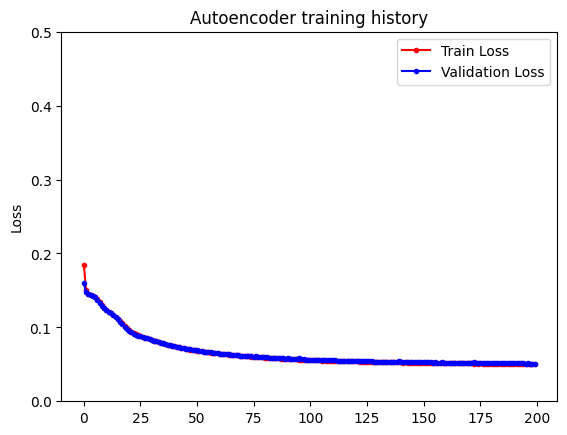

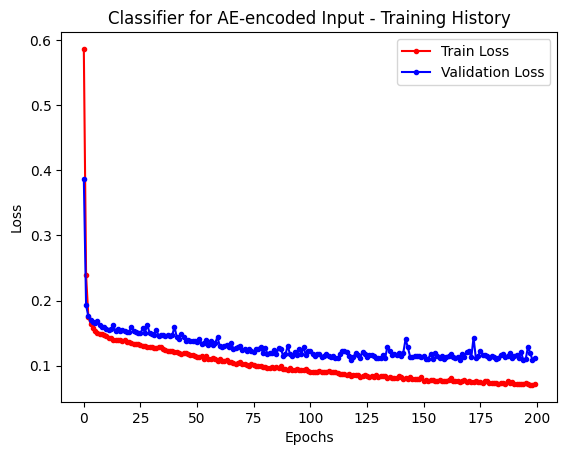

In [12]:
fig, ax = plt.subplots()
ax.plot(multi_model_history.history["Decoder_loss"],'r', marker='.', label="Train Loss")
ax.plot(multi_model_history.history["val_Decoder_loss"],'b', marker='.', label="Validation Loss")
ax.set_ylabel("Loss")
ax.set_ylim([0, 0.5])

# ax_r = ax.twinx()
# ax_r.plot(multi_model_history.history['Decoder_reconstruction_accuracy'], marker='.', label="Train Rconstruction Accuracy")
# ax_r.plot(multi_model_history.history['val_Decoder_reconstruction_accuracy'], marker='.', label="Validation Reconstruction Accuracy")
# ax_r.set_ylabel("Reconstruction Accuracy")
# #ax_r.set_ylim([0.75, 1])
# final_reconstruction_acc_val = multi_model_history.history['val_Decoder_reconstruction_accuracy'][-1]
# ax_r.plot(
#     ax_r.get_xlim(), 
#     [final_reconstruction_acc_val, final_reconstruction_acc_val],
#     'k-',
#     label=f"Final reconstruction accuracy Validation: {final_reconstruction_acc_val*100:.2f}%"
#     )

ax.set_title("Autoencoder training history")
ax.legend()
#ax.set_xlim(-10, 400)

# lines1, labels1 = ax.get_legend_handles_labels()
# lines2, labels2 = ax_r.get_legend_handles_labels()
# ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

fig, ax = plt.subplots()
ax.plot(multi_model_history.history["Classifier_loss"],'r', marker='.', label="Train Loss")
ax.plot(multi_model_history.history["val_Classifier_loss"],'b', marker='.', label="Validation Loss")
ax.set_title("Classifier for AE-encoded Input - Training History")
ax.set_ylabel("Loss")
ax.set_xlabel("Epochs")
ax.legend()

In [14]:
from sklearn.metrics import classification_report

preds = full_multi_output_model.predict(X_one_hot)[1]
print(classification_report(y_scaled, [0 if pred < 0.5 else 1 for pred in preds]))

346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      4898
           1       0.98      0.95      0.97      6157

    accuracy                           0.96     11055
   macro avg       0.96      0.96      0.96     11055
weighted avg       0.96      0.96      0.96     11055



## Interpretability

346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 654us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step
346/346 ━━━━━━━━━━━━━

Text(0.5, 1.0, 'Heatmap for latent space sensitivity')

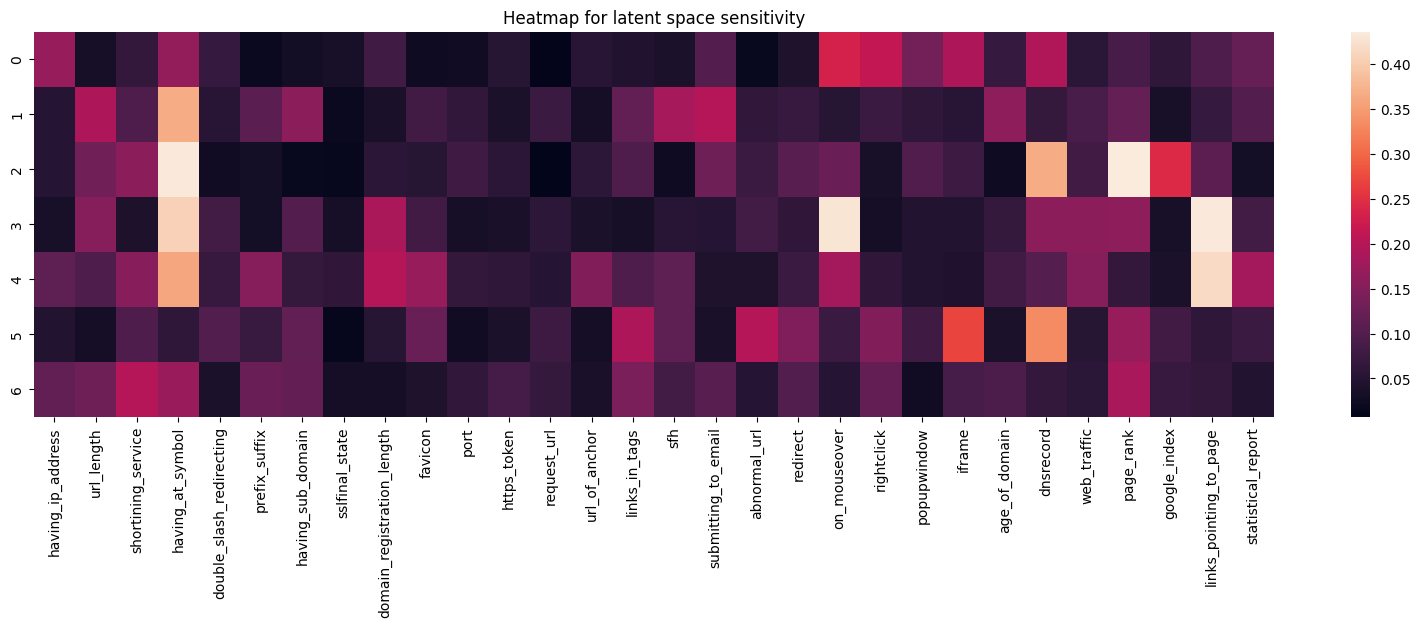

In [17]:
def latent_sensitivity(encoder, X, feature_index):
    X_copy = X.copy()
    X_copy.iloc[:, feature_index] = 1 - X_copy.iloc[:, feature_index]  # flip bit
    original = encoder.predict(X)
    perturbed = encoder.predict(X_copy)
    return np.mean(np.abs(perturbed - original), axis=0)

sensitivity_data = {}
for i, feature in enumerate(X_scaled.columns):
    sensitivity_data[feature] = latent_sensitivity(enc, X_one_hot.drop(columns=exclude_from_dim_red_cols), i)

sensitivity_df = pd.DataFrame(sensitivity_data)

plt.figure(figsize=(20, 5))
sns.heatmap(sensitivity_df)
plt.title("Heatmap for latent space sensitivity")

346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step


c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


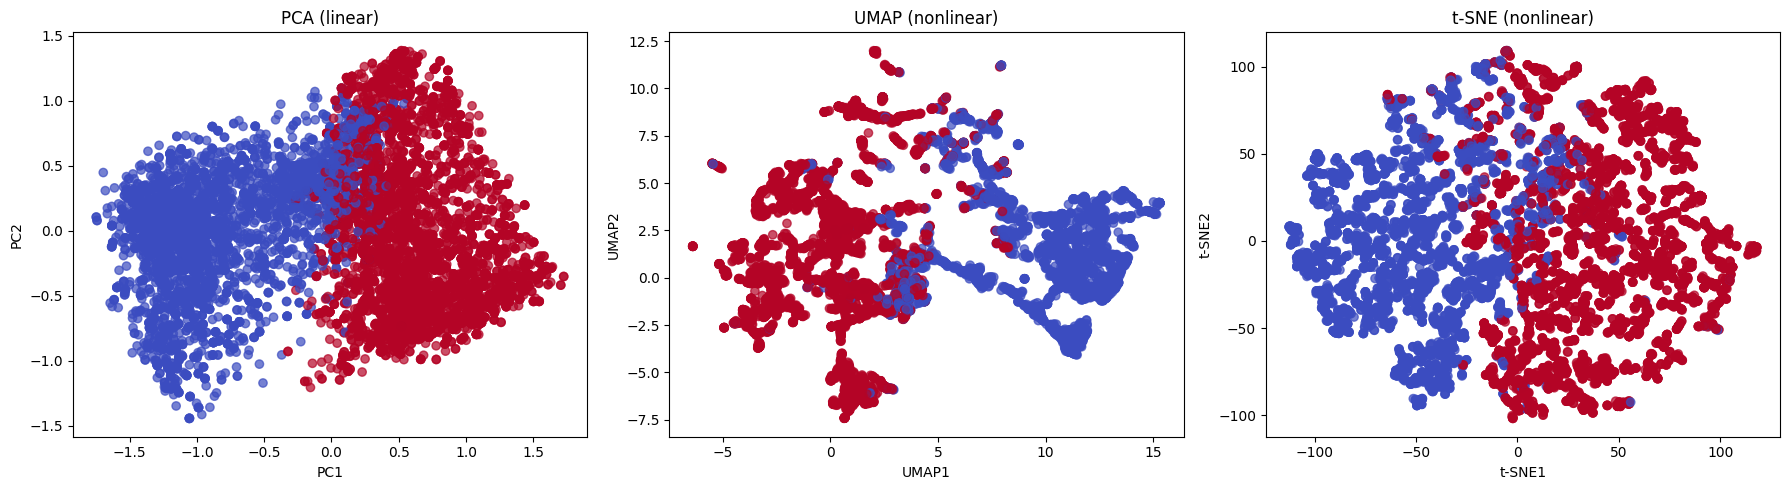

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# ---- 1. Encode data ----
X_encoded = enc.predict(X_one_hot.drop(columns=exclude_from_dim_red_cols))

# ---- 2. PCA ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded)

# ---- 3. UMAP ----
# Add noise to help the eigensolver initialise better
X_noisy = X_encoded + 0.01 * np.random.randn(*X_encoded.shape)
# Forcing the number of neighbors helps with a simple manifold
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=50, min_dist=0.1)
X_umap = umap_model.fit_transform(X_noisy)

# ---- 4. t-SNE ----
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_encoded)

# ---- 5. Plot all three ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_scaled.to_numpy(), cmap='coolwarm', alpha=0.7)
axes[0].set_title("PCA (linear)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# UMAP
axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=y_scaled.to_numpy(), cmap='coolwarm', alpha=0.7)
axes[1].set_title("UMAP (nonlinear)")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

# t-SNE
axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_scaled.to_numpy(), cmap='coolwarm', alpha=0.7)
axes[2].set_title("t-SNE (nonlinear)")
axes[2].set_xlabel("t-SNE1")
axes[2].set_ylabel("t-SNE2")

plt.tight_layout()
plt.show()

346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step


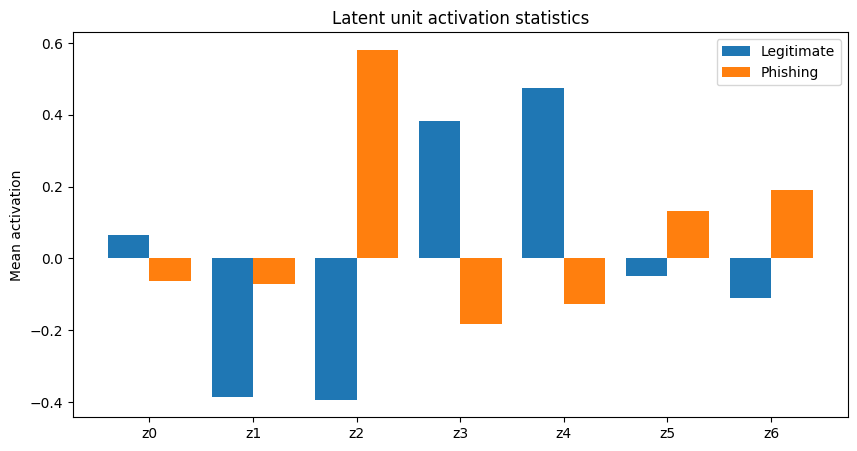

In [23]:
X_encoded = enc.predict(X_one_hot.drop(columns=exclude_from_dim_red_cols))

X_phish = X_encoded[(y_scaled == 1).to_numpy().reshape(-1)]
X_legit = X_encoded[(y_scaled == 0).to_numpy().reshape(-1)]

mean_phish = np.mean(X_phish, axis=0)
mean_legit = np.mean(X_legit, axis=0)

std_phish = np.std(X_phish, axis=0)
std_legit = np.std(X_legit, axis=0)

diff = mean_phish - mean_legit

units = np.arange(X_encoded.shape[1])

plt.figure(figsize=(10,5))
plt.bar(units - 0.2, mean_legit, width=0.4, label='Legitimate')
plt.bar(units + 0.2, mean_phish, width=0.4, label='Phishing')
plt.xticks(units, [f"z{i}" for i in units])
plt.ylabel("Mean activation")
plt.title("Latent unit activation statistics")
plt.legend()
plt.show()


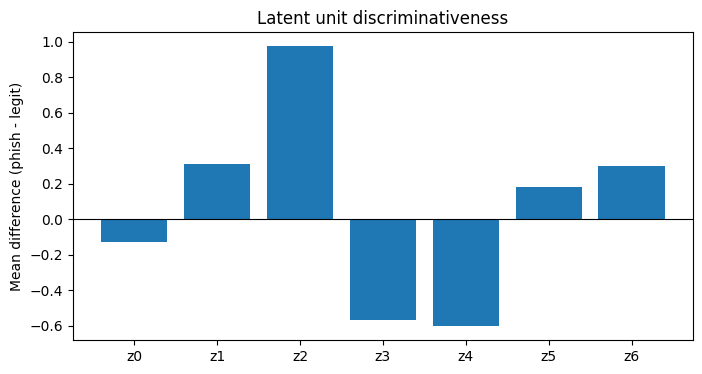

In [25]:
plt.figure(figsize=(8,4))
plt.bar(units, (diff))
plt.xticks(units, [f"z{i}" for i in units])
plt.ylabel("Mean difference (phish - legit)")
plt.title("Latent unit discriminativeness")
plt.axhline(0, color='black', linewidth=0.8)
plt.show()